# Exploratory Data Analysis: Cardiac Arrhythmia Dataset

This notebook explores the cardiac arrhythmia ECG dataset to inform preprocessing and modeling decisions.

**Dataset**: OpenML Cardiac Arrhythmia (Dataset #5)  
**Samples**: 452 patient ECG recordings  
**Features**: 279 (206 numeric + 73 nominal)  
**Classes**: 16 arrhythmia types

## 1. Setup and Data Loading

In [1]:
import sys
from pathlib import Path

# Add src directory to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load dataset
from data_loader import load_arff

data_file = Path.cwd().parent / 'data' / 'dataset_5_arrhythmia.arff'
if not data_file.exists():
    # Try parent directory
    data_file = Path.cwd().parent.parent / 'dataset_5_arrhythmia.arff'

df, meta = load_arff(str(data_file))
print(f"Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")
print(f"\nDataset info:")
print(df.info())

Dataset loaded: 452 samples, 280 features

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Columns: 280 entries, age to class
dtypes: float64(206), object(74)
memory usage: 988.9+ KB
None


## 2. Dataset Overview

In [3]:
# Basic statistics
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"Total samples: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")
print(f"\nFeature types:")
print(df.dtypes.value_counts())
print(f"\nNumeric columns: {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include=['object']).shape[1]}")
print(f"\nFirst few rows:")
df.head()

DATASET OVERVIEW
Total samples: 452
Total features: 280

Feature types:
float64    206
object      74
Name: count, dtype: int64

Numeric columns: 206
Categorical columns: 74

First few rows:


,age,sex,height,weight,QRSduration,PRinterval,Q-Tinterval,Tinterval,Pinterval,QRS,...,chV6_QwaveAmp,chV6_RwaveAmp,chV6_SwaveAmp,chV6_RPwaveAmp,chV6_SPwaveAmp,chV6_PwaveAmp,chV6_TwaveAmp,chV6_QRSA,chV6_QRSTA,class
0,75.0,0,190.0,80.0,91.0,193.0,371.0,174.0,121.0,-16.0,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56.0,1,165.0,64.0,81.0,174.0,401.0,149.0,39.0,25.0,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54.0,0,172.0,95.0,138.0,163.0,386.0,185.0,102.0,96.0,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55.0,0,175.0,94.0,100.0,202.0,380.0,179.0,143.0,28.0,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75.0,0,190.0,80.0,88.0,181.0,360.0,177.0,103.0,-16.0,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


## 3. Missing Values Analysis

In [4]:
# Check for missing values
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct_nonzero = missing_pct[missing_pct > 0]

print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Columns with missing values: {len(missing_pct_nonzero)}")
print(f"\nTop 20 columns with missing values:")
print(missing_pct_nonzero.head(20))

Total missing values: 408
Columns with missing values: 5

Top 20 columns with missing values:
'J'          83.185841
'P'           4.867257
'T'           1.769912
QRST          0.221239
heartrate     0.221239
dtype: float64


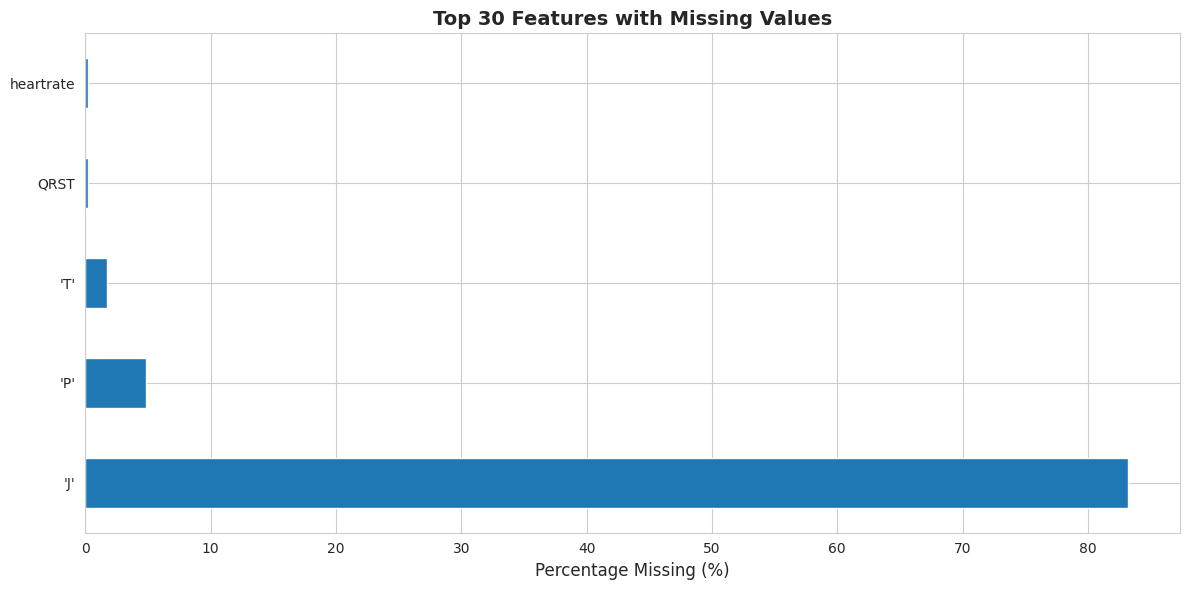


Rows with at least one missing value: 384 (85.0%)


In [5]:
# Visualize missing data
if len(missing_pct_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_pct_nonzero.head(30).plot(kind='barh', ax=ax)
    ax.set_xlabel('Percentage Missing (%)', fontsize=12)
    ax.set_title('Top 30 Features with Missing Values', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Rows with missing values
    rows_with_missing = df.isnull().any(axis=1).sum()
    print(f"\nRows with at least one missing value: {rows_with_missing} ({rows_with_missing/len(df)*100:.1f}%)")
else:
    print("No missing values found!")

## 4. Class Distribution Analysis

In [14]:
# Class distribution
target_col = 'class'
if target_col in df.columns:
    class_counts = df[target_col].value_counts().sort_index()
    print("Class Distribution:")
    print(class_counts)
    print(f"\nClass proportions:")
    print(class_counts / len(df))
    print(f"\nClass imbalance ratio (max/min): {class_counts.max() / class_counts.min():.2f}")

Class Distribution:
class
1     245
10     50
14      4
15      5
16     22
2      44
3      15
4      15
5      13
6      25
7       3
8       2
9       9
Name: count, dtype: int64

Class proportions:
class
1     0.542035
10    0.110619
14    0.008850
15    0.011062
16    0.048673
2     0.097345
3     0.033186
4     0.033186
5     0.028761
6     0.055310
7     0.006637
8     0.004425
9     0.019912
Name: count, dtype: float64

Class imbalance ratio (max/min): 122.50


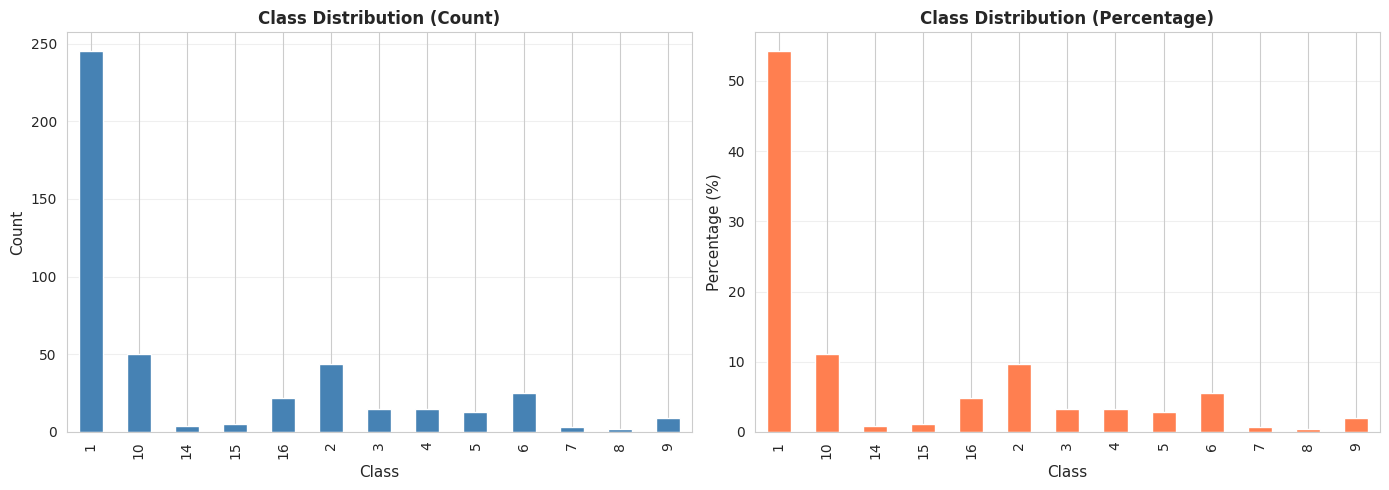

In [15]:
# Visualize class distribution
if target_col in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    class_counts.plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Class', fontsize=11)
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Proportion plot
    (class_counts / len(df) * 100).plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Class', fontsize=11)
    axes[1].set_ylabel('Percentage (%)', fontsize=11)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 5. Feature Distribution Analysis

In [16]:
# Get numeric features (excluding target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

print(f"Numeric features: {len(numeric_cols)}")
print(f"\nBasic statistics for first 5 numeric features:")
print(df[numeric_cols[:5]].describe())

Numeric features: 206

Basic statistics for first 5 numeric features:
              age      height      weight  QRSduration  PRinterval
count  452.000000  452.000000  452.000000   452.000000  452.000000
mean    46.471239  166.188053   68.170354    88.920354  155.152655
std     16.466631   37.170340   16.590803    15.364394   44.842283
min      0.000000  105.000000    6.000000    55.000000    0.000000
25%     36.000000  160.000000   59.000000    80.000000  142.000000
50%     47.000000  164.000000   68.000000    86.000000  157.000000
75%     58.000000  170.000000   79.000000    94.000000  175.000000
max     83.000000  780.000000  176.000000   188.000000  524.000000


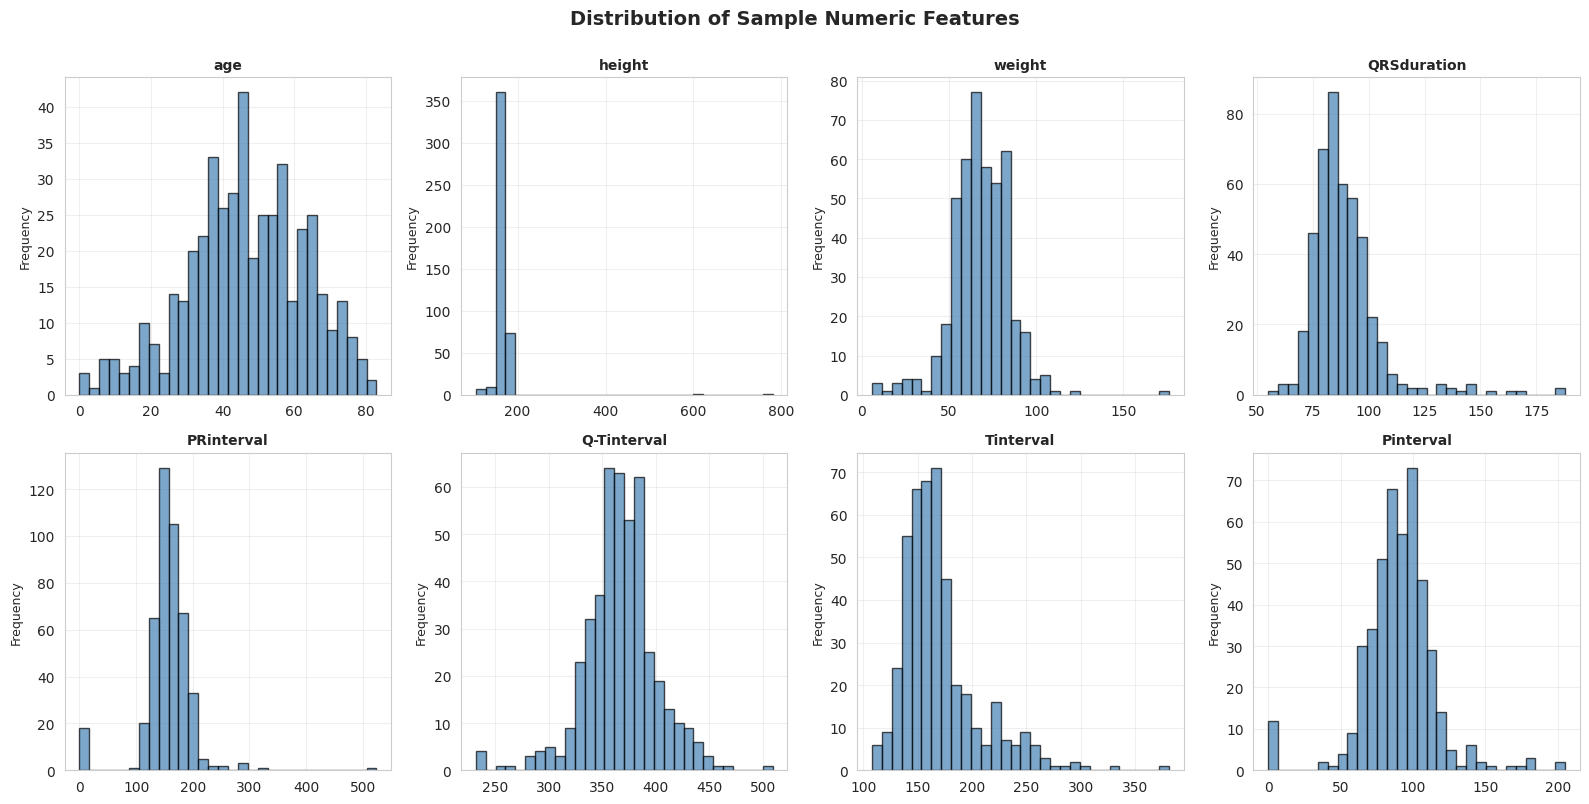

In [17]:
# Distribution of numeric features (sample)
sample_features = numeric_cols[:8] if len(numeric_cols) >= 8 else numeric_cols

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(sample_features):
    axes[idx].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontsize=9)
    axes[idx].grid(alpha=0.3)

# Hide unused subplots
for idx in range(len(sample_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribution of Sample Numeric Features', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 6. Feature Correlation Analysis

In [18]:
# Correlation matrix for numeric features
corr_matrix = df[numeric_cols].corr()

# Find highly correlated features
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"Highly correlated feature pairs (|r| > 0.9): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nTop 10 most correlated pairs:")
    sorted_pairs = sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]
    for feat1, feat2, corr in sorted_pairs:
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")

Highly correlated feature pairs (|r| > 0.9): 19

Top 10 most correlated pairs:
  chAVR_SPwave <-> chAVR_SPwaveAmp: -1.000
  chV4_SPwave <-> chV4_SPwaveAmp: -0.999
  chV6_RPwave <-> chV6_RPwaveAmp: 0.998
  chAVF_SPwave <-> chAVF_SPwaveAmp: -0.967
  chV3_SPwave <-> chV3_RPwaveAmp: 0.967
  chV1_SPwave <-> chV1_SPwaveAmp: -0.958
  chV2_SPwave <-> chV2_SPwaveAmp: -0.953
  chAVL_RPwave <-> chAVL_RPwaveAmp: 0.942
  chDIII_SPwave <-> chDIII_SPwaveAmp: -0.941
  chDI_Qwave <-> chDI_QwaveAmp: -0.937


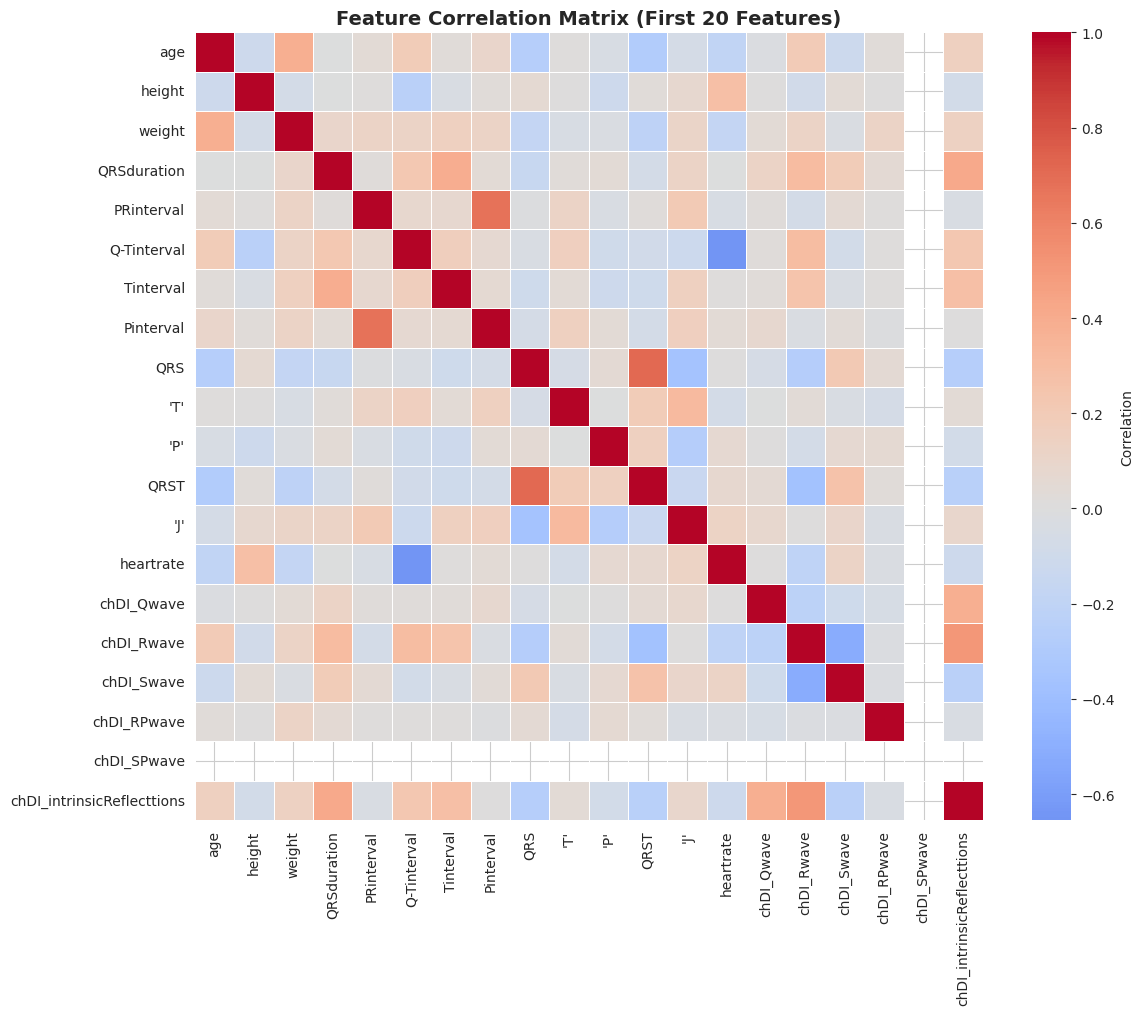

In [19]:
# Correlation heatmap (sample of features)
sample_size = min(20, len(numeric_cols))
sample_corr = df[numeric_cols[:sample_size]].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(sample_corr, cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title(f'Feature Correlation Matrix (First {sample_size} Features)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Key Insights and Recommendations

In [12]:
print("="*80)
print("KEY INSIGHTS AND PREPROCESSING RECOMMENDATIONS")
print("="*80)

print("\n1. MISSING VALUES:")
if len(missing_pct_nonzero) > 0:
    print(f"   - {len(missing_pct_nonzero)} features have missing values")
    print(f"   - {rows_with_missing} rows ({rows_with_missing/len(df)*100:.1f}%) have at least one missing value")
    print(f"   - RECOMMENDATION: Drop rows with missing values (preserve ~{(1-rows_with_missing/len(df))*100:.1f}% of data)")
else:
    print("   - No missing values found")

print("\n2. CLASS IMBALANCE:")
if target_col in df.columns:
    imbalance_ratio = class_counts.max() / class_counts.min()
    print(f"   - Imbalance ratio: {imbalance_ratio:.2f}x (max/min)")
    if imbalance_ratio > 3:
        print(f"   - RECOMMENDATION: Use class_weight='balanced' in all models")
        print(f"   - RECOMMENDATION: Use StratifiedKFold for CV to preserve class proportions")
        print(f"   - RECOMMENDATION: Prioritize macro F1 over accuracy for evaluation")

print("\n3. FEATURE SCALING:")
print(f"   - RECOMMENDATION: Apply StandardScaler to numeric features")
print(f"   - RATIONALE: Required for SVM and MLP; helpful for Logistic Regression")
print(f"   - RATIONALE: Fit scaler on train+val, apply to test for reproducibility")

print("\n4. MULTICOLLINEARITY:")
if len(high_corr_pairs) > 0:
    print(f"   - {len(high_corr_pairs)} feature pairs have |r| > 0.9")
    print(f"   - RECOMMENDATION: Skip feature selection for now; let algorithms handle it")
else:
    print(f"   - Low multicollinearity detected")

print("\n5. CATEGORICAL FEATURES:")
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)
print(f"   - {len(cat_cols)} categorical features (excluding target)")
print(f"   - RECOMMENDATION: Use LabelEncoder for categorical features")

print("\n" + "="*80)

KEY INSIGHTS AND PREPROCESSING RECOMMENDATIONS

1. MISSING VALUES:
   - 5 features have missing values
   - 384 rows (85.0%) have at least one missing value
   - RECOMMENDATION: Drop rows with missing values (preserve ~15.0% of data)

2. CLASS IMBALANCE:

3. FEATURE SCALING:
   - RECOMMENDATION: Apply StandardScaler to numeric features
   - RATIONALE: Required for SVM and MLP; helpful for Logistic Regression
   - RATIONALE: Fit scaler on train+val, apply to test for reproducibility

4. MULTICOLLINEARITY:
   - 19 feature pairs have |r| > 0.9
   - RECOMMENDATION: Skip feature selection for now; let algorithms handle it

5. CATEGORICAL FEATURES:
   - 74 categorical features (excluding target)
   - RECOMMENDATION: Use LabelEncoder for categorical features



## 8. Summary Statistics

In [13]:
# Create a summary report
summary = {
    'Total Samples': df.shape[0],
    'Total Features': df.shape[1],
    'Numeric Features': len(numeric_cols),
    'Categorical Features': len(cat_cols),
    'Target Classes': len(df[target_col].unique()) if target_col in df.columns else 'N/A',
    'Rows with Missing Values': rows_with_missing if len(missing_pct_nonzero) > 0 else 0,
    'Features with Missing Values': len(missing_pct_nonzero),
    'Class Imbalance Ratio': f"{class_counts.max() / class_counts.min():.2f}x" if target_col in df.columns else 'N/A'
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
print("\nSUMMARY STATISTICS:")
print(summary_df.to_string(index=False))


SUMMARY STATISTICS:
                      Metric Value
               Total Samples   452
              Total Features   280
            Numeric Features   206
        Categorical Features    74
              Target Classes   N/A
    Rows with Missing Values   384
Features with Missing Values     5
       Class Imbalance Ratio   N/A
